In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# DataBlock Understanding with Image Classification

## Highlights
- Single Label Classification with datablock 
- different way to use datablocks parameteric vs empty
- label vs non label parameters where non label we will get label same as url
- Comparisons we can check below
- dataloders give additional capability for example show batch



## Question Datablock
- what is the types of your inputs/targets? Here images and categories
- where is your data? Here in filenames in subfolders
- does something need to be applied to inputs? Here no
- does something need to be applied to the target? Here the label_func function
- how to split the data? Here randomly
- do we need to apply something on formed items? Here a resize
- do we need to apply something on formed batches? Here no


In [ ]:
dblock = DataBlock(blocks    = (ImageBlock, CategoryBlock),
                   get_items = get_image_files,
                   get_y     = label_func,
                   splitter  = RandomSplitter(),
                   item_tfms = Resize(224))

For two questions that got a no, the corresponding arguments we would pass if the anwser was different would be get_x and batch_tfms.

## Classifier with Empty Datablock to Parametric
1. **[Tutorials](https://docs.fast.ai/)** Go tutorial-->Intermediate-->Datablock
2. **[DataBlock](https://docs.fast.ai/data.block.html)**
3. **[torch image models](https://timm.fast.ai/)** Model Architecture find out Replace this model name in Learner of fastai, Models are already trained

## We will build Two Classifiers

- One is in fastai Document
- One I will Search

## Some Links
- [Path](https://realpython.com/get-all-files-in-directory-python/)
- [Path](https://stackoverflow.com/questions/34439/finding-what-methods-a-python-object-has)

### Import Datasets and Vision

In [1]:
from fastai.data.all import *
from fastai.vision.all import *

### dataset untar  
- URLs
- PET dataset
- untar function to unzip
  
**return** links

In [2]:
path = untar_data(URLs.PETS)


In [3]:
path

Path('/root/.fastai/data/oxford-iiit-pet')

## List of Files in Path Directory
https://realpython.com/get-all-files-in-directory-python/ 
https://stackoverflow.com/questions/34439/finding-what-methods-a-python-object-has

In [4]:
dir(path)
print("print all the Methods of object")

print all the Methods of object


In [5]:
#help(Path)
print("help give documentry")

help give documentry


In [6]:
??path.iterdir

Signature: path.iterdir()
Source:   
    def iterdir(self):
        """Iterate over the files in this directory.  Does not yield any
        result for the special paths '.' and '..'.
        """
        for name in self._accessor.listdir(self):
            if name in {'.', '..'}:
                # Yielding a path object for these makes little sense
                continue
            yield self._make_child_relpath(name)
File:      /usr/lib/python3.10/pathlib.py
Type:      method


In [7]:
hasattr(path,"iterdir")


True

In [8]:
list(path.iterdir())

[Path('/root/.fastai/data/oxford-iiit-pet/images'),
 Path('/root/.fastai/data/oxford-iiit-pet/annotations')]

## Extract Image from URL [get_image_files](https://docs.fast.ai/data.transforms.html#get_image_files)
- give folder contains image files
- recursive true means if subfolders

**return** path of all the images in given filder directory


In [9]:
fnames = get_image_files(path/"images")

In [10]:
fnames
print("paths of all the images in given filder directory")

path of all the images in given filder directory


## [Datablock](https://docs.fast.ai/data.block.html#datablock) Empty
- Data assemble thing
- it has types regressionblock, multiblock, transformervlock
- dataloaders and dataset are methods of it

### **Purpose**
- have batch we can check DataBlock.datasets()


In [11]:
dblock = DataBlock()

### Note
fnames are links so we dont use dataloaders

In [12]:
dsets = dblock.datasets(fnames)


In [15]:
dsets[1]

(Path('/root/.fastai/data/oxford-iiit-pet/images/boxer_18.jpg'),
 Path('/root/.fastai/data/oxford-iiit-pet/images/boxer_18.jpg'))

In [ ]:
dsets = dblock.datasets(path/"image")
print("Error : we did not provide information for how to ")

In [19]:
len(dsets.train), len(dsets.valid),

(5912, 1478)

## [Datablock](https://docs.fast.ai/data.block.html#datablock) Function get_items
- get items we will take computational function
- resrved fastai **get_image_files** which extact images in current directory
- we can design our own


In [22]:
dblock = DataBlock(get_items=get_image_files)

In [23]:
dsets = dblock.datasets(path/"images")
dsets.train[0]

(Path('/root/.fastai/data/oxford-iiit-pet/images/american_pit_bull_terrier_148.jpg'),
 Path('/root/.fastai/data/oxford-iiit-pet/images/american_pit_bull_terrier_148.jpg'))

## Comparison 1 :Empty vs prameteric DataBlock
- Datablock with get_items
- without it

In [30]:
##
path = untar_data(URLs.PETS)

print(list(path.iterdir()))
#--------Way 1 Empty--------
dblock = DataBlock()
dset=dblock.datasets(get_image_files(path/"images"))
print("Size of Train dataset",len(dset.train))

#--------Way 1 Parametric--------
dblock = DataBlock(get_items=get_image_files)
dset2=dblock.datasets( path/"images") # path/"images"
print("Size of Train dataset",len(dset2.train))

[Path('/root/.fastai/data/oxford-iiit-pet/images'), Path('/root/.fastai/data/oxford-iiit-pet/annotations')]
Size of Train dataset 5912
Size of Train dataset 5912


In [35]:
dset.train[0]

(Path('/root/.fastai/data/oxford-iiit-pet/images/american_pit_bull_terrier_144.jpg'),
 Path('/root/.fastai/data/oxford-iiit-pet/images/american_pit_bull_terrier_144.jpg'))

## Datablock Label Function
- we use get_y and pass function for it
- our filenames we have filenames which have first capital letter is cat
- we can check

In [29]:
def label_func(fname):
    return "cat" if fname.name[0].isupper() else "dog"

In [36]:
dblock = DataBlock(get_items = get_image_files,
                   get_y = label_func)

dsets = dblock.datasets(path/"images")
dsets.train[0]

(Path('/root/.fastai/data/oxford-iiit-pet/images/leonberger_137.jpg'), 'dog')

## Compare 2:  Label vs No Label
- dset.train[0] previously label was equal to image url path

- (Path('/root/.fastai/data/oxford-iiit-pet/images/american_pit_bull_terrier_148.jpg'),
 **Path('/root/.fastai/data/oxford-iiit-pet/images/american_pit_bull_terrier_148.jpg**

vs

- (Path('/root/.fastai/data/oxford-iiit-pet/images/leonberger_137.jpg'), **'dog'**)


## Add block Type
- In datablock we are adding Block Type
- we will not have links anymore it will be image PIL

In [45]:
dblock = DataBlock(blocks = (ImageBlock, CategoryBlock),
                   get_items = get_image_files,
                   get_y = label_func)

dsets = dblock.datasets(path/"images")
dsets.train[0]

(PILImage mode=RGB size=500x375, TensorCategory(1))

## Comparison 3 : blocks added vs no
- (PILImage mode=RGB size=500x378, TensorCategory(1))

- (Path('/root/.fastai/data/oxford-iiit-pet/images/leonberger_137.jpg'), **'dog'**)


In [39]:
dsets.vocab

['cat', 'dog']

## Multiple Category we can

- we can pass multiple blocks
-  n_inp we should give
- get_x we need to specify 

## splitter
- Random valid and train data

In [46]:
dblock = DataBlock(blocks = (ImageBlock, CategoryBlock),
                   get_items = get_image_files,
                   get_y = label_func,
                  splitter=RandomSplitter())

dsets = dblock.datasets(path/"images")
dsets.train[0]

(PILImage mode=RGB size=500x357, TensorCategory(0))

## Items transform
- we can crop or resize or anything we can apply

In [43]:
dblock = DataBlock(blocks    = (ImageBlock, CategoryBlock),
                   get_items = get_image_files,
                   get_y     = label_func,
                   splitter  = RandomSplitter(),
                   item_tfms = Resize(224))
dsets = dblock.datasets(path/"images")
dsets.train[0]

(PILImage mode=RGB size=300x225, TensorCategory(1))

## Comparison 4 : size changes
(PILImage mode=RGB size=500x357, TensorCategory(0)) --> (PILImage mode=RGB size=300x225, TensorCategory(1))



# Batching with Dataloaders
- we need to use dataloaders for batching not datasets


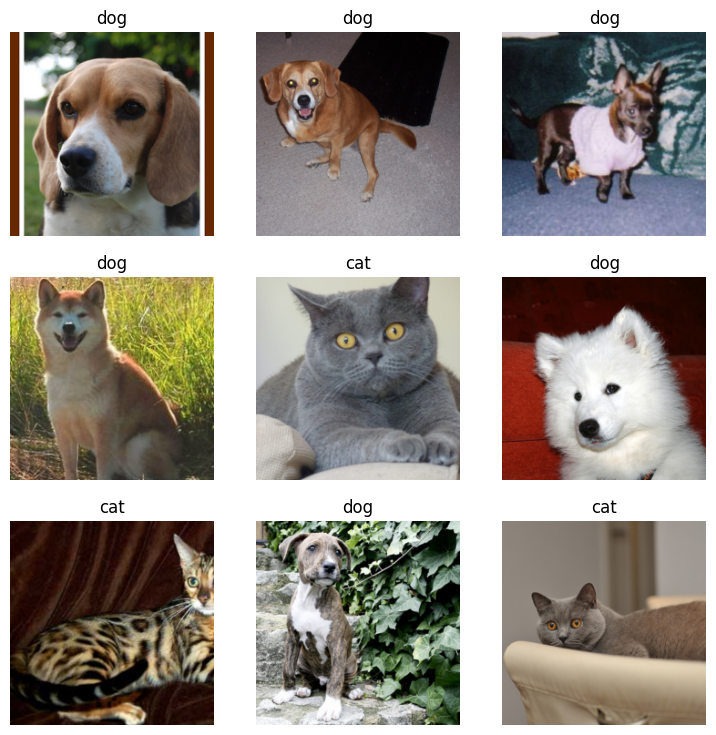

In [47]:
dblock = DataBlock(blocks    = (ImageBlock, CategoryBlock),
                   get_items = get_image_files,
                   get_y     = label_func,
                   splitter  = RandomSplitter(),
                   item_tfms = Resize(224))
dls = dblock.dataloaders(path/"images")
dls.show_batch()

## Comparison : dataset produce no batch but dataloders
- dsets = dblock.datasets(path/"images") --> dls = dblock.dataloaders(path/"images")
- dsets.show_batch() not work